# Input

In [89]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import warnings
import matplotlib
import matplotlib.pyplot as plt
import sys 
import os 
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np
import seaborn as sns
from tqdm import tqdm
import subprocess
from sklearn.metrics import r2_score

import pandas as pd
from scipy.stats import linregress
import matplotlib.patches as mpatches
from scipy.stats import pearsonr, spearmanr
from pandas.api.types import CategoricalDtype
from scipy.cluster.hierarchy import linkage
from matplotlib.patches import Patch
from statsmodels.stats.multitest import multipletests
# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_colwidth', None)
# np.set_printoptions(threshold=np.inf)

plt.rcParams["figure.figsize"]=4,4

warnings.filterwarnings("ignore")

# - dirs 
from ciim.src.common import palette_genders, palette_treatment, mapping_major_2_minor, mapping_minor_2_major, cell_types, datasets_e, datasets_all, datasets_a, palette_datasets, palette_datasets_pretty, surrogate_names, colors_blind, palette_trend, palette_trend_2, palette_regulation, palette_cell_types

from ciim.src.tf_activity.helper import retrieve_feature_data, retrieve_adata_bulk, retrieve_net, calculate_tf_activity, retrieve_sig_stats
# from ciim.src.tf_activity.plots import  plot_net_nx, plot_trend_tfs

from ciim.src.clock.helper import save_dir


# - settings
feature_type = 'tf_activity' # 'tf_activity' gene_expression
data_type = 'bulk_minor'
reg_type = 'ridge'
tune_model = False
version = 'v1.0'

cell_types = ['CD8T', 'MONO'] # ['CD4T','CD8T', 'MONO', 'B', 'NK']
n_cell_types = len(cell_types)
datasets_training = ['data1', 'data7_allTPs_jalil', 'SLE_European', 'data13_Japanese']

In [6]:
from ciim.src.clock.helper import prepare_input
cell_type = 'CD8T'
data_type = 'bulk_minor'

adata_store = []
for dataset in datasets_training:
    adata = prepare_input(dataset, cell_type, feature_type=feature_type, data_type=data_type)
    if 'SLE' in dataset:
        adata = adata[adata.obs['disease']=='normal'].copy()
    adata_store.append(adata)
adata_all = ad.concat(adata_store, join='inner', axis=0)

data1 (3324, 232)
data7_allTPs_jalil (1227, 232)
SLE_European (578, 232)
data13_Japanese (568, 232)


In [37]:
import pandas as pd
from scipy.sparse import issparse

def pivot_adata_minor(adata):
    adata.obs['Major_CT'] = adata.obs['Major_CT'].astype('str')
    adata.obs['Sub_CT'] = adata.obs['Sub_CT'].astype('str')
    adata.obs['donor_age'] = adata.obs['donor_id'].astype('str') + '_' + adata.obs['age'].astype('str')

    X = adata.X.toarray() if issparse(adata.X) else adata.X
    expr_df = pd.DataFrame(X, index=adata.obs_names, columns=adata.var_names)

    # Attach metadata
    expr_df['Major_CT'] = adata.obs['Major_CT'].values
    expr_df['Sub_CT'] = adata.obs['Sub_CT'].values
    expr_df['donor_age'] = adata.obs['donor_age'].values

    # Melt into long format
    melted = expr_df.melt(id_vars=['Major_CT', 'Sub_CT', 'donor_age'], var_name='gene', value_name='expression')

    # Create gene_Sub_CT column
    melted['gene_sub'] = melted['gene'] + '_' + melted['Sub_CT']

    # - pivot and reformat
    pivot = melted.pivot_table(index=['Major_CT', 'donor_age'], columns='gene_sub', values='expression')
    obs = pd.DataFrame(pivot.index.tolist(), columns=pivot.index.names)
    adata_pivot = ad.AnnData(X=pivot.values, obs=obs, var=pd.DataFrame(index=pivot.columns))

    original_cols = adata.obs.columns
    to_merge = [col for col in original_cols if col not in ['Sub_CT']]
    adata_pivot.obs = adata_pivot.obs.merge(adata.obs[to_merge].drop_duplicates(subset=['donor_age']), on='donor_age', how='left')
    return adata_pivot
adata_pivot = pivot_adata_minor(adata_all)

In [30]:
adata

AnnData object with n_obs × n_vars = 568 × 232
    obs: 'sum_by', 'batch_info', 'Major_CT', 'Sub_CT', 'dataset', 'sex', 'race', 'age_donor', 'age_group', 'cell_type', 'orig.ident', 'age', 'batch_group', 'donor_id', 'cell_count', 'donor_age'
    var: 'source'

In [ ]:
gene_names = adata_all.var_names.values

X = adata_all.X
y = adata_all.obs['age']

# Previous aging model

In [3]:
if False:
    dataset = 'SLE_European' #'SLE_European' #'CXCL9' 
    data_file = f"/vol/projects/jnourisa/datasets/{dataset}_metacell.h5ad"
    output_file = f'../output/clock/{dataset}.csv'
    r_script_path = "../src/clock/AgeingClock_application_h5ad.R"
    if dataset == 'SLE_European':
        condition = 'disease'
    elif dataset == 'CXCL9':
        condition = 'treatment'
    else:
        condition = 'nada'


    result = subprocess.run(
        ["Rscript", r_script_path, data_file, output_file, condition],
        capture_output=True, text=True
    )
    print("STDOUT:\n", result.stdout)
    print("STDERR:\n", result.stderr)
    if result.returncode != 0:
        print("R script failed.")
    else:
        print("R script executed successfully.")
    
    df_all = pd.read_csv(output_file, sep="\t")
    df_all_bulk = df_all.groupby(['donor_id', 'cell_type', 'condition', 'age', 'sex'])['predicted_age'].median().reset_index()
    df_all_bulk.head()

# Train

In [42]:
if True:
    import subprocess

    cmd = [
        "python", "../src/clock/script.py",
        "--cell_types", *cell_types,
        "--datasets_training", *datasets_training,
        "--feature_type", feature_type,
        "--data_type", data_type,
        "--reg_type", reg_type,
        "--version", version,

    ]
    if tune_model:
        cmd += ["--tune_model"]

    print("Running:", " ".join(cmd))
    subprocess.run(cmd, check=True)

Running: python ../src/clock/script.py --cell_types CD8T MONO --datasets_training data1 data7_allTPs_jalil SLE_European data13_Japanese --feature_type tf_activity --data_type bulk_minor --reg_type ridge --version v1.0
{'cell_types': ['CD8T', 'MONO'], 'datasets_training': ['data1', 'data7_allTPs_jalil', 'SLE_European', 'data13_Japanese'], 'feature_type': 'tf_activity', 'data_type': 'bulk_minor', 'reg_type': 'ridge', 'tune_model': False, 'version': 'v1.0'}
building model for cell type: CD8T
data1 (3324, 232)


/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


pivoted (980, 928)
data7_allTPs_jalil (1227, 232)


/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


pivoted (313, 928)
SLE_European (578, 232)
pivoted (150, 928)


...

/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


pivoted (313, 750)
SLE_European (300, 375)
pivoted (150, 750)


/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


data13_Japanese (293, 375)
pivoted (147, 750)


/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


# Evaluation

In [43]:
force_write = True

In [80]:
from ciim.src.clock.helper import predict_age, prepare_input
# evaluate_datasets = ['data1', 'data7_allTPs_jalil', 'SLE_European',  'data13_Japanese', 'data12', 'data13_Korean' ,  'CXCL9'] # 'data1', 'data7_allTPs_jalil', 'data12', 'SLE_European', 'data13_Korean' , 'data13_Japanese', 
evaluate_datasets = ['CXCL9']
prediction_file = f'{save_dir}/prediction/{feature_type}_{data_type}_{reg_type}.csv'
if (force_write) or not os.path.exists(prediction_file):
    os.makedirs(f'{save_dir}/prediction', exist_ok=True)
    obs_store = []
    for cell_type in cell_types:
        for dataset in evaluate_datasets:
            adata = prepare_input(dataset, cell_type, feature_type=feature_type, data_type=data_type)
            adata.obs.rename(columns={'disease': 'condition', 'treatment':'condition'}, inplace=True)
            if 'condition' not in adata.obs.columns:
                adata.obs['condition'] = 'healthy'
            conds = adata.obs['condition'].unique()
            for cond in conds:
                adata_c = adata[adata.obs['condition'] == cond]
                adata_c = predict_age(adata_c, cell_type, feature_type=feature_type, data_type=data_type, reg_type=reg_type)
                obs = adata_c.obs[['age', 'predicted_age', 'sex', 'donor_id']].copy() 
                obs['dataset'] = dataset
                obs['cell_type'] = cell_type
                obs['condition'] = cond
                obs_store.append(obs)
    obs = pd.concat(obs_store, axis=0)
    obs.to_csv(prediction_file, index=False)
else:
    obs = pd.read_csv(prediction_file)
obs.head()

CXCL9 (305, 232)
pivoted (77, 1160)
{'Spearman': 0.03603749850782236, 'R2': -64.1786522819784}
{'Spearman': -0.43244998209386837, 'R2': -15.830224123028383}
{'Spearman': 0.10811249552346709, 'R2': -11.268355488808782}
{'Spearman': -0.5225437283634242, 'R2': -36.85806514375508}
{'Spearman': 0.23424374030084538, 'R2': -14.436935235699998}
{'Spearman': 0.09009374626955591, 'R2': -12.875411092425443}
{'Spearman': 0.30631873731649006, 'R2': -12.297568122715692}
{'Spearman': -0.23424374030084538, 'R2': -20.7107424204897}
{'Spearman': 0.34235623582431246, 'R2': -20.206861531152178}
{'Spearman': 0.34235623582431246, 'R2': -27.04136799096245}
{'Spearman': 0.396412483586046, 'R2': -10.377186887557475}
CXCL9 (143, 375)
pivoted (77, 1125)
{'Spearman': -0.4504687313477795, 'R2': -105.12938435645714}
{'Spearman': -0.6666937223947136, 'R2': -235.48303381978974}
{'Spearman': -0.14414999403128945, 'R2': -161.5698627321247}
{'Spearman': -0.34235623582431246, 'R2': -104.55393076048942}
{'Spearman': -0.68

,age,predicted_age,sex,donor_id,dataset,cell_type,condition
0,29,41.512431,Male,CXCL9_TI_A,CXCL9,CD8T,0 h Unstimulated
11,28,26.665848,Female,CXCL9_TI_B,CXCL9,CD8T,0 h Unstimulated
22,31,50.737365,Male,CXCL9_TI_C,CXCL9,CD8T,0 h Unstimulated
33,25,48.206669,Female,CXCL9_TI_D,CXCL9,CD8T,0 h Unstimulated
44,29,18.163540,Male,CXCL9_TI_E,CXCL9,CD8T,0 h Unstimulated


## Performance on train data

### Line plot

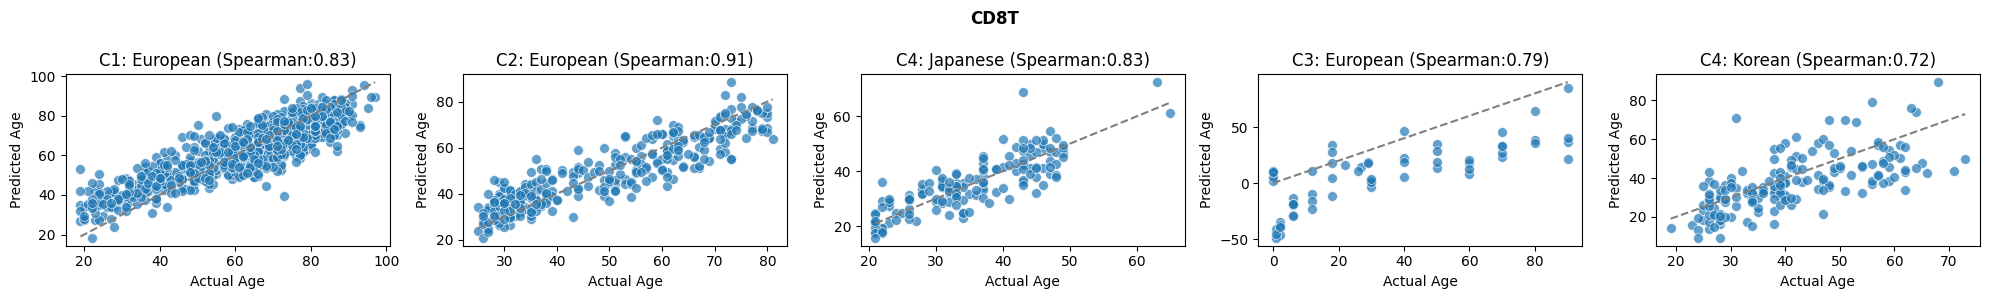

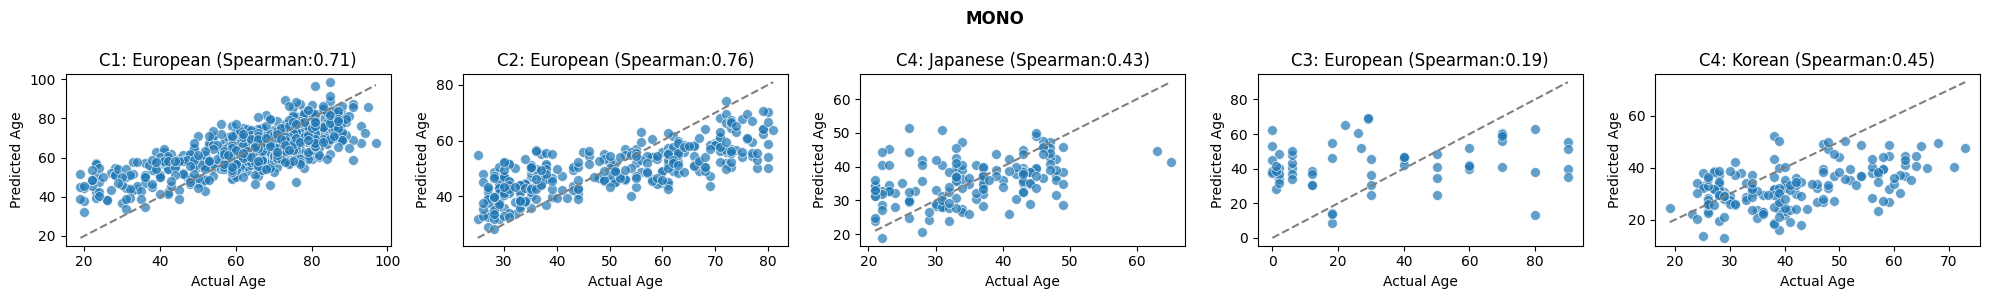

In [57]:
from ciim.src.clock.helper import evaluate_groupwise_median

datasets_healthy = obs[(obs['condition'] == 'healthy')]['dataset'].unique()

if True:
    for cell_type in cell_types:
        fig, axes = plt.subplots(1, len(datasets_healthy), figsize=(4*len(datasets_healthy), 3))
        i = 0
        for dataset in datasets_healthy:
            ax = axes[i] if len(datasets_healthy) > 1 else axes
            df = obs[(obs['cell_type'] == cell_type) & (obs['dataset'] == dataset)].copy()
            obs_d = df.groupby(['donor_id', 'age'])['predicted_age'].median().reset_index()

            sns.scatterplot(data=obs_d, x='age', y='predicted_age', s=50, alpha=0.7, ax=ax, palette=palette_genders)
            min_age, max_age = obs_d['age'].min(), obs_d['age'].max()
            ax.plot([min_age, max_age], [min_age, max_age], color='gray', linestyle='--', label='Ideal')

            ax.set_xlabel("Actual Age")
            ax.set_ylabel("Predicted Age")
            spearman = evaluate_groupwise_median(obs_d)['Spearman']
            ax.set_title(f"{surrogate_names[dataset]} (Spearman:{spearman:.2f})")
            
            i+=1
        
        plt.suptitle(cell_type, fontsize=12, weight='bold')
        plt.tight_layout()

### Summary plot

In [58]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from scipy.stats import spearmanr
from ciim.src.clock.helper import evaluate_groupwise_median


datasets_healthy = ['data1', 'data7_allTPs_jalil', 'SLE_European' ,'data13_Japanese', 'data12', 'data13_Korean'] 

scores = []
for cell_type in cell_types:
    for dataset in datasets_healthy:
        df = obs[(obs['cell_type'] == cell_type) & (obs['dataset'] == dataset)].copy()
        obs_d = df.groupby(['donor_id', 'age'])['predicted_age'].median().reset_index()

        rr = evaluate_groupwise_median(obs_d)
        spearman = rr['Spearman']
        r2 =  rr['R2']

        scores.append({
            'cell_type': cell_type,
            'dataset': dataset,
            'Spearman': spearman,
            'R2': r2
        })
scores_df = pd.DataFrame(scores)
scores_long = scores_df.melt(id_vars=['cell_type', 'dataset'], 
                              value_vars=['Spearman', 'R2'], 
                              var_name='metric', value_name='score')
scores_long['dataset'] = scores_long['dataset'].apply(lambda name: surrogate_names.get(name, name))
scores_long.head()

,cell_type,dataset,metric,score
0,CD8T,C1: European,Spearman,0.832812
1,CD8T,C2: European,Spearman,0.905130
2,CD8T,C5: European,Spearman,0.768078
3,CD8T,C4: Japanese,Spearman,0.831824
4,CD8T,C3: European,Spearman,0.789363


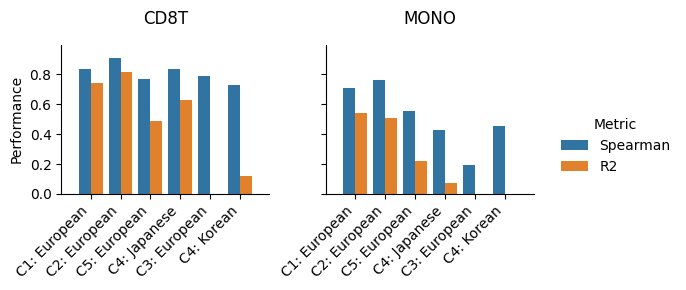

In [59]:
def multipanel_plot():
    fig, axes = plt.subplots(1, len(cell_types), figsize=(3*len(cell_types)+1, 3), sharey=True)
    for i, (cell_type) in enumerate(cell_types):
        ax = axes[i] if len(cell_types) > 1 else axes
        df_s = scores_long[scores_long['cell_type'] == cell_type]
        df_s['score'] = df_s['score'].clip(lower=0, upper=1) # clip the scores

        sns.barplot(
                ax=ax,
                data=df_s,
                x='dataset', y='score', hue='metric')
        ax.set_title(f"{cell_type}", pad=15)
        ax.set_ylabel("Performance")
        ax.set_xlabel("")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.get_legend().remove()
        ax.spines[['top', 'right']].set_visible(False)
        ax.margins(y=.1, x=.1)
    ax.legend(loc=(1.1, .1), title='Metric', frameon=False, fontsize=10)
    
    plt.tight_layout()
    
multipanel_plot()

#### ridge

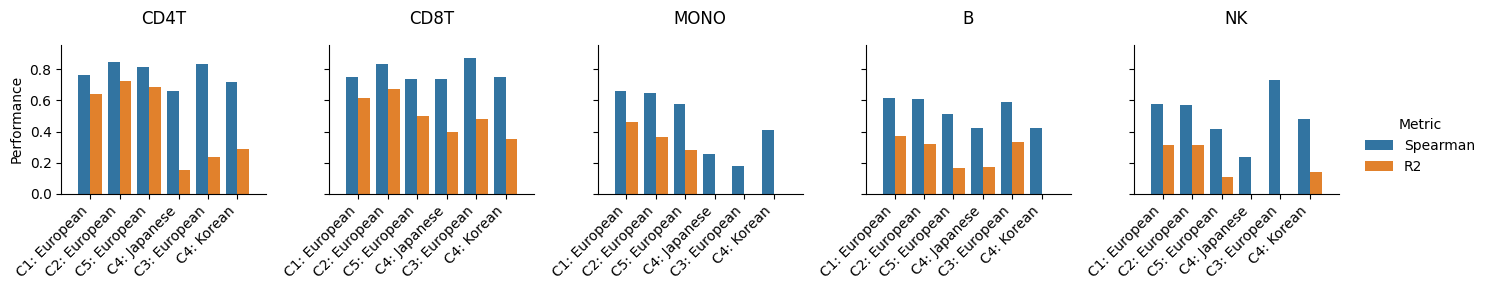

## Performance on SLE

In [60]:
obs_sle = obs[obs['dataset'] == 'SLE_European'].copy()
conds = obs_sle['condition'].unique()

### Line plot

In [61]:
import scipy.stats as stats

if False:

    for cell_type in cell_types:
        fig, axes = plt.subplots(1, len(conds), figsize=(4*len(conds), 3))
        for i, cond in enumerate(conds):
            ax = axes[i] if len(conds) > 1 else axes
            obs_d = obs_sle[(obs_sle['cell_type'] == cell_type) & (obs_sle['condition'] == cond)].copy()
            obs_d = obs_d.groupby(['donor_id', 'age'])['predicted_age'].median().reset_index()
            # - plot the goodness
            age_diff = obs_d['predicted_age'] - obs_d['age']
            
            # One-sample t-test
            t_stat, p_value = stats.ttest_1samp(age_diff, 0)
            mean_diff = age_diff.mean()
            
            # plt.title(f"{cond}\np = {p_value:.4g}, Mean age diff = {mean_diff:.2f}")

            sns.scatterplot(data=obs_d, x='age', y='predicted_age', s=50, alpha=0.7, ax=ax, palette=palette_genders)
            min_age, max_age = obs_d['age'].min(), obs_d['age'].max()
            ax.plot([min_age, max_age], [min_age, max_age], color='gray', linestyle='--', label='Ideal')

            ax.set_xlabel("Actual Age")
            ax.set_ylabel("Predicted Age")

            spearman = spearmanr(obs_d['age'], obs_d['predicted_age'])[0]
            ax.set_title(f"{surrogate_names[cond]} (Spearman:{spearman:.2f}) \n (Mean diff: {mean_diff:.2f}, p_value: {p_value:.4g})")
            # ax.get_legend().remove()
            
            i+=1
        
        # ax.legend(loc=(1.05, .2), frameon=False)
        plt.suptitle(cell_type, fontsize=12, weight='bold')
        plt.tight_layout()


### Bin plot

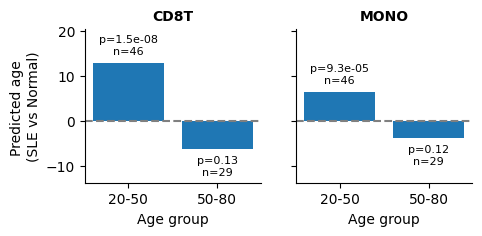

In [62]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
import numpy as np

obs_sle = obs[obs['dataset'] == 'SLE_European'].copy()
obs_sle['age'] = obs_sle['age'].astype(int)
obs_sle['donor_id'] = obs_sle['donor_id'].astype(str)
conds = obs_sle['condition'].unique()
age_bins = pd.interval_range(start=20, end=80, freq=30)  # adjust range if needed

fig, axes = plt.subplots(1, n_cell_types, figsize=(2.5*n_cell_types, 2), sharey=True)
for i, cell_type in enumerate(cell_types):
    ax = axes[i] if len(cell_types) > 1 else axes
    # Prepare data
    obs_ct = obs_sle[obs_sle['cell_type'] == cell_type].copy()
    obs_ct = obs_ct.groupby(['donor_id', 'age', 'condition'])['predicted_age'].median().reset_index()
    obs_ct['age_bin'] = pd.cut(obs_ct['age'], bins=age_bins)

    # Iterate over conditions (excluding 'normal')
    cond = 'systemic lupus erythematosus'

    if cond not in obs_ct['condition'].unique():
        raise ValueError(f"Condition '{cond}' not found in the data.")
    bar_vals = []
    bar_labels = []
    bar_pos = []

    for j, age_bin in enumerate(age_bins):
        norm_vals = obs_ct[(obs_ct['condition'] == 'normal') & (obs_ct['age_bin'] == age_bin)]['predicted_age']
        cond_vals = obs_ct[(obs_ct['condition'] == cond) & (obs_ct['age_bin'] == age_bin)]['predicted_age']

        if len(norm_vals) >= 3 and len(cond_vals) >= 3:  # minimum sample size
            tstat, pval = ttest_ind(cond_vals, norm_vals, equal_var=False)
            diff = cond_vals.mean() - norm_vals.mean()
            label = f"p={pval:.2g}\nn={len(cond_vals)}"
        else:
            diff = np.nan
            label = "n<3"

        bar_vals.append(diff)
        bar_labels.append(label)
        bar_pos.append(j)

    # Plot
    bars = ax.bar(bar_pos, bar_vals, tick_label=[f"{int(bin.left)}-{int(bin.right)}" for bin in age_bins])
    ax.axhline(0, linestyle='--', color='gray')
    ax.set_title(f"{cell_type}", weight='bold', fontsize=10)
    ax.set_xlabel("Age group")
    if i == 0:
        ax.set_ylabel("Predicted age \n(SLE vs Normal)")

    # Add annotations
    for bar, label in zip(bars, bar_labels):
        height = bar.get_height()
        ax.annotate(label,
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 5 if height >= 0 else -5),
                    textcoords="offset points",
                    ha='center', va='bottom' if height >= 0 else 'top',
                    fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)
    ax.margins(y=0.4)

    # plt.suptitle(f"{cell_type} — Predicted Age Shift vs Normal", fontsize=13)
    # plt.tight_layout()

## Drug perturbation

In [81]:
obs_cxcl9 = obs[obs['dataset'] == 'CXCL9'].copy() 
obs_cxcl9['condition'].unique()

array(['0 h Unstimulated', '24 h LPS', '24 h LPS + metformin',
       '24 h LPS + metformin + ruxolitinib', '24 h LPS + ruxolitinib',
       '24 h RPMI', '24 h RPMI + metformin',
       '24 h RPMI + metformin + ruxolitinib', '24 h RPMI + ruxolitinib',
       '24 h rhCXCL9', '24 h rhIFN-γ'], dtype=object)

In [82]:
pretty_names = {
    '24 h LPS': 'LPS',
    '24 h LPS + metformin': 'LPS+Metformin',
    '24 h LPS + metformin + ruxolitinib': 'LPS+Met.+Rux.', #Ruxolitinib
    '24 h LPS + ruxolitinib': 'LPS+Rux.',
    '24 h RPMI': 'RPMI',
    '24 h RPMI + metformin': 'RPMI+Metformin',
    '24 h RPMI + metformin + ruxolitinib': 'RPMI+Met.+Rux.',
    '24 h RPMI + ruxolitinib': 'RPMI+Rux.',
    '24 h RPMI': 'RPMI',
    '24 h rhCXCL9': 'rhCXCL9',
    '24 h rhIFN-γ': 'rhIFN-γ'
}

experiments = [
                # ('24 h RPMI', '24 h rhCXCL9'),
                ('24 h RPMI', '24 h LPS'),
                # ('24 h RPMI', '24 h rhIFN-γ'),
                ('24 h RPMI', '24 h RPMI + metformin'),
                ('24 h RPMI', '24 h RPMI + ruxolitinib'),
                # ('24 h RPMI', '24 h RPMI + metformin + ruxolitinib'),
                ('24 h LPS', '24 h LPS + metformin'),
                ('24 h LPS', '24 h LPS + ruxolitinib'),
                # ('24 h LPS', '24 h LPS + metformin + ruxolitinib'),
                ]
n_exp = len(experiments)

In [84]:
from statsmodels.stats.multitest import multipletests

# Store raw p-values and labels for later correction
raw_pvals = []
test_labels = []  # e.g., f"{cell_type}_{ctr}_vs_{treatment}"
slopes = []

def test_paired(df_sub):
    df_pivot = df_sub.pivot(index='donor_id', columns='condition', values='predicted_age').dropna()
    t_stat, p_value = stats.ttest_rel(df_pivot[treatment], df_pivot[ctr])
    slope = (df_pivot[treatment] - df_pivot[ctr]).mean()
    return p_value, slope

def test_mixed_effect(df_sub):
    import statsmodels.formula.api as smf
    df_sub['condition'] = pd.Categorical(df_sub['condition'], categories=[ctr, treatment])
    # Fit the mixed effects model
    model = smf.mixedlm("predicted_age ~ condition", df_sub, groups=df_sub["donor_id"])
    result = model.fit()
    # # Summary of the model
    # print(result.summary())
    # Extract p-value and fixed effect estimate for treatment
    p_value = result.pvalues[f"condition[T.{treatment}]"]
    slope = result.params[f"condition[T.{treatment}]"]
    return p_value, slope
for cell_type in obs_cxcl9['cell_type'].unique():
    obs_t = obs_cxcl9[obs_cxcl9['cell_type'] == cell_type].copy()
    df_all = obs_t[['donor_id', 'condition', 'predicted_age']].copy()

    for i, (ctr, treatment) in enumerate(experiments):
        df_sub = df_all[df_all['condition'].isin([ctr, treatment])].copy()
        if df_sub.shape[0] < 2:
            continue  # Skip if not enough data
        
        if 'bulk' in data_type:
            p_value, slope = test_paired(df_sub)

        elif data_type == 'metacell':
            df_sub = df_sub.groupby(['donor_id', 'condition'])['predicted_age'].median().reset_index()
            p_value, slope = test_paired(df_sub)
            # p_value, slope = test_mixed_effect(df_sub)
        else:
            raise ValueError("Unsupported data type")
        raw_pvals.append(p_value)
        slopes.append(slope)
        test_labels.append((cell_type, ctr, treatment))

# Apply FDR correction
rejected, corrected_pvals, _, _ = multipletests(raw_pvals, method='fdr_bh')

# Optionally: map corrected p-values back to plotting
pval_map = {
    (cell_type, ctr, treatment): (pval, slope)
    for (cell_type, ctr, treatment), pval, slope in zip(test_labels, corrected_pvals, slopes)
}

# Redraw plots with adjusted p-values
unique_donors = obs_cxcl9['donor_id'].unique()
donor_palette = dict(zip(unique_donors, sns.color_palette("husl", len(unique_donors))))  # or use 'tab20', 'Set3', etc.


### All sig and not sig ones

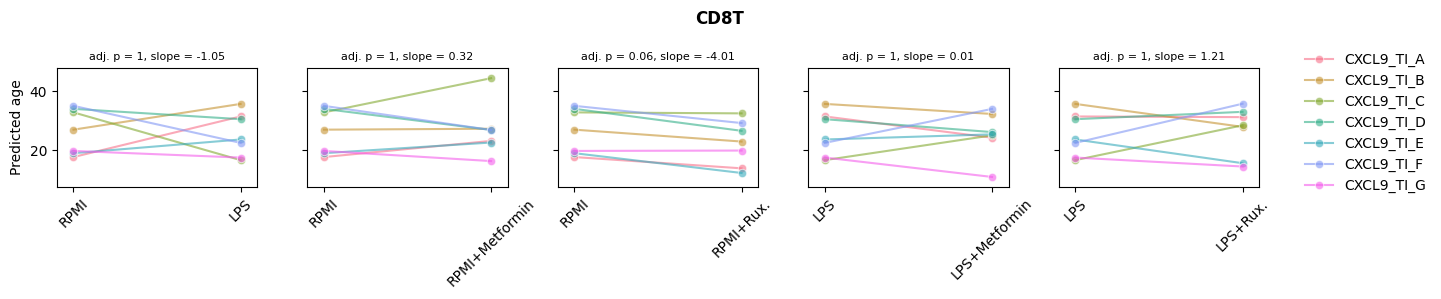

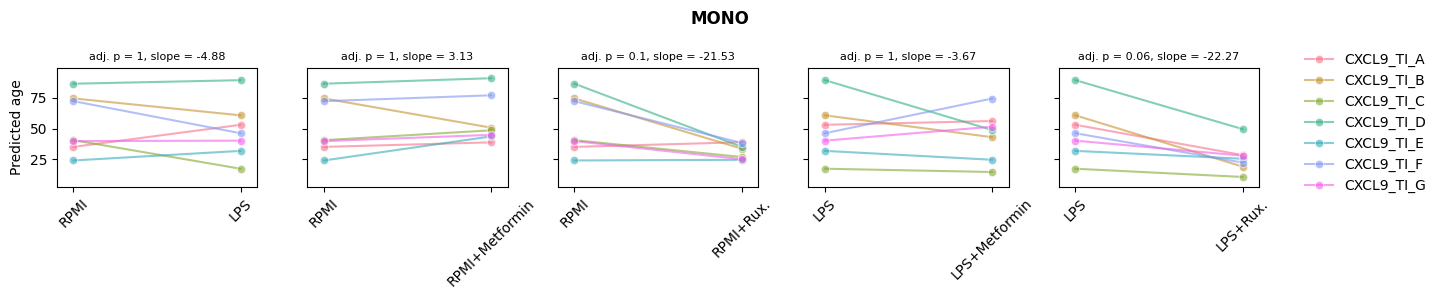

In [85]:


for cell_type in cell_types:
    obs_t = obs_cxcl9[obs_cxcl9['cell_type'] == cell_type].copy()
    df_all = obs_t[['donor_id', 'condition', 'predicted_age']].copy()
    fig, axes = plt.subplots(1, n_exp, figsize=(2.5*n_exp+2, 3), sharey=True)

    for i, (ctr, treatment) in enumerate(experiments):
        ax = axes[i] if n_exp > 1 else axes
        df_sub = df_all[df_all['condition'].isin([ctr, treatment])].copy()
        df_pivot = df_sub.pivot_table(index='donor_id', columns='condition', values='predicted_age')

        available_conditions = [cond for cond in [ctr, treatment] if cond in df_pivot.columns]
        df_plot = df_pivot.reset_index().melt(id_vars='donor_id', 
                                      value_vars=available_conditions,
                                      var_name='condition', 
                                      value_name='predicted_age')
        
        df_plot['condition'] = df_plot['condition'].map(pretty_names)
        sns.lineplot(data=df_plot, x='condition', y='predicted_age', 
                     hue='donor_id', marker='o', alpha=0.6, legend=True, ax=ax, palette=donor_palette)
        
        pval, slope = pval_map.get((cell_type, ctr, treatment), (1.0, 0))
        ax.set_title(f"adj. p = {pval:.1g}, slope = {slope:.2f}", fontsize=8)
        ax.set_ylabel("Predicted age")
        ax.set_xlabel("")
        ax.margins(x=0.1, y=0.1)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
        ax.get_legend().remove()
    ax.legend(loc=(1.2, -.1), frameon=False)
    plt.suptitle(cell_type, fontsize=12, weight='bold')
    plt.tight_layout()

### Only sig ones

In [86]:
alpha = 0.05  # significance threshold

for cell_type in cell_types:
    obs_t = obs_cxcl9[obs_cxcl9['cell_type'] == cell_type].copy()
    df_all = obs_t[['donor_id', 'condition', 'predicted_age']].copy()

    # Get only the significant experiments for this cell type
    significant_experiments = [
        (ctr, treatment) for (ctr, treatment) in experiments
        if pval_map.get((cell_type, ctr, treatment), (1.0, 0))[0] < alpha
    ]
    if not significant_experiments:
        continue  # skip plotting if no significant pairs

    fig, axes = plt.subplots(1, len(significant_experiments), figsize=(2 * len(significant_experiments) + 1, 3), sharey=True)
    if len(significant_experiments) == 1:
        axes = [axes]  # make it iterable

    for i, (ctr, treatment) in enumerate(significant_experiments):
        ax = axes[i]
        df_sub = df_all[df_all['condition'].isin([ctr, treatment])].copy()
        df_pivot = df_sub.pivot_table(index='donor_id', columns='condition', values='predicted_age')
        
        # Only donors with both conditions
        df_pivot = df_pivot.dropna(subset=[ctr, treatment], how='any')

        df_plot = df_pivot.reset_index().melt(
            id_vars='donor_id', 
            value_vars=[ctr, treatment], 
            var_name='condition', 
            value_name='predicted_age'
        )

        df_plot['condition'] = df_plot['condition'].map(pretty_names)
        sns.lineplot(
            data=df_plot,
            x='condition', y='predicted_age',
            hue='donor_id', marker='o', alpha=0.6,
            ax=ax, palette=donor_palette, legend=False
        )

        pval, slope = pval_map.get((cell_type, ctr, treatment), (1.0, 0))
        ax.set_title(f"{pretty_names.get(ctr, ctr)} vs {pretty_names.get(treatment, treatment)}\n"
                     f"adj. p = {pval:.1g}, slope = {slope:.2f}", fontsize=9)
        ax.set_xlabel("")
        ax.set_ylabel("Predicted Age")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
        ax.margins(x=0.1, y=0.1)

    fig.suptitle(cell_type, fontsize=12, weight='bold')
    fig.tight_layout()
    plt.show()

# TF perturbation

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy import stats

from ciim.src.tf_activity.helper import retrieve_sig_stats


def compute_tf_slopes(adata, sig_tfs):
    sig_tfs = [tf for tf in sig_tfs if tf in adata.var_names]
    adata_sig = adata[:, sig_tfs].copy()
    X = pd.DataFrame(adata_sig.X, columns=adata_sig.var_names)
    ages = adata_sig.obs['age'].astype(float).values.reshape(-1, 1)
    slopes = {}
    for tf in adata_sig.var_names:
        tf_values = X[tf].values.reshape(-1, 1)
        if np.all(np.isnan(tf_values)) or np.all(tf_values == tf_values[0]):
            continue
        model = LinearRegression()
        model.fit(ages, tf_values)
        slopes[tf] = model.coef_.item()

    slope_df = pd.DataFrame.from_dict(slopes, orient='index', columns=['slope'])
    return slope_df


def perturb_tf(adata, tfs, slope_df, years=10):
    print('Number of tfs to perturb: ', len(tfs))
    expr_df = pd.DataFrame(adata.X, columns=adata.var_names)
    for tf in tfs:
        if tf in adata.var_names and tf in slope_df.index:
            delta = slope_df.loc[tf].values
            if pd.isna(delta):
                continue
            expr_df[tf] += delta * years

    adata_perturb = adata.copy()
    adata_perturb.X = expr_df.values
    return adata_perturb


def perform_stat_test(adata_combined, ctr='baseline', treatment='perturb'):
    df_all = adata_combined.obs.copy()
    df_sub = df_all[df_all['condition'].isin([ctr, treatment])].copy()
    df_pivot = df_sub.pivot(index='donor_age', columns='condition', values='predicted_age')
    df_pivot = df_pivot.dropna(subset=[ctr, treatment])
    if (df_pivot[ctr]==df_pivot[treatment]).all():
        raise ValueError("No difference between conditions")
    t_stat, p_value = stats.ttest_rel(df_pivot[treatment], df_pivot[ctr])
    slope = (df_pivot[treatment] - df_pivot[ctr]).mean()
    return df_pivot, t_stat, p_value, slope

def plot_results(df_pivot, t_stat, p_value, slope, ctr='baseline', treatment='perturb'):
    if True: # line plot
        fig, ax = plt.subplots(figsize=(4, 4))
        sns.scatterplot(data=df_pivot, x=ctr, y=treatment, alpha=0.7, ax=ax)
        min_age, max_age = df_pivot[ctr].min(), df_pivot[treatment].max()
        ax.plot([min_age, max_age], [min_age, max_age], color='gray', linestyle='--', label='Ideal')

    if False: # donor plot
        df_plot = df_pivot.reset_index().melt(id_vars='donor_age', 
                                            value_vars=[ctr, treatment],
                                            var_name='condition', 
                                            value_name='predicted_age')

        plt.figure(figsize=(3, 2.5))
        sns.lineplot(data=df_plot, x='condition', y='predicted_age', 
                    hue='donor_age', marker='o', alpha=0.6, legend=False)

        plt.title(f"p = {p_value:.4g}, Change after 10 years = {slope:.2f}")
        plt.ylabel("Predicted age")
        plt.tight_layout()
        plt.show()

def experiment_perturb(data_type, dataset, cell_type, n_donors, reg_type='ridge'):
    # - prepare the input and select donors 
    adata = prepare_input(dataset, cell_type, feature_type='tf_activity', data_type=data_type)
    adata.obs['donor_age'] = adata.obs['donor_id'].astype(str) + '_' + adata.obs['age'].astype(str)
    donors = adata.obs['donor_age'].unique()
    np.random.seed(0)
    donors = np.random.choice(donors, n_donors, replace=False)
    adata = adata[adata.obs['donor_age'].isin(donors)]

    # - get the significant TFs and compute slopes
    if perturb_coverage == 'aging_tfs': # perturb the sig tfs 
        print('Perturbing the aging TFs')
        stats_sig = retrieve_sig_stats(type='bulk', race='both', filter_inconsistent=True)
        stats_sig = stats_sig[stats_sig['cell_type'] == cell_type]
        tfs = stats_sig['tf'].unique()
    elif perturb_coverage == 'all_tfs': # perturb all tfs
        print('Perturbing all TFs')
        tfs = adata.var_names
    else:
        raise ValueError("perturb_coverage should be either 'aging_tfs' or 'all_tfs'")
    slope_df = compute_tf_slopes(adata.copy(), tfs)

    if trend == 'increase':
        slope_df = slope_df
    elif trend == 'decrease':
        slope_df = -slope_df
    else:
        raise ValueError("trend should be either 'increase' or 'decrease'")

    # - perturb the TFs and create a new adata object
    adata_perturb = perturb_tf(adata.copy(), tfs, slope_df)

    # - combine the adatas and predict age
    adata.obs['condition'] = 'baseline'
    adata_perturb.obs['condition'] = 'perturb'
    adata_combined = ad.concat([adata, adata_perturb], axis=0)
    adata_combined = predict_age(adata_combined, cell_type, feature_type='tf_activity', data_type=data_type, reg_type=reg_type)

    # - plots
    df_pivot, t_stat, p_value, slope = perform_stat_test(adata_combined)
    print(f"Paired t-test: t = {t_stat:.3f}, p = {p_value:.4g}")
    print(f"Mean difference (slope): {slope:.3f}")

    plot_results(df_pivot, t_stat, p_value, slope)


data7_allTPs_jalil (623, 375)
pivoted (313, 750)
Perturbing the aging TFs
Number of tfs to perturb:  50
{'Spearman': 0.5470279953381426, 'R2': 0.39233637051725123}


ValueError: No difference between conditions

In [93]:
# Run the experiment
cell_type = 'CD8T'
trend = 'increase' # apply the aging slope or opposite
perturb_coverage = 'aging_tfs' # all_tfs
n_donors = 20

experiment_perturb(data_type, dataset='data1', cell_type=cell_type, n_donors=n_donors, reg_type=reg_type)
experiment_perturb(data_type, dataset='data7_allTPs_jalil', cell_type=cell_type, n_donors=n_donors, reg_type=reg_type)

data1 (3324, 232)
pivoted (980, 928)
Perturbing the aging TFs
Number of tfs to perturb:  153
{'Spearman': 0.8615502815160567, 'R2': 0.7394103418534037}


ValueError: No difference between conditions